<a href="https://colab.research.google.com/github/Opsimtech/CFD-ML-model/blob/main/Flettner_PINN_NCp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flettner Rotor PINN — NCp=8 Focused Run
**Goal: minimise Cp MAE and recover correct suction peak depth.**
- Re=3.6e5, α=2.0, 8 uniformly spaced pressure sensors
- N_INT=2000 (restored — 800 was too sparse)
- Sensor positions shown on all Cp plots
- Clear section structure

**Run cells in order: 1 → 2 → 3 → 4 → 5**

## Section 1 — Setup and Parameters

In [1]:
# ─────────────────────────────────────────────────────────────────
# SECTION 1: PARAMETERS
# All tunable settings in one place. Change only here.
# ─────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os, numpy as np, pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size":11, "figure.dpi":120})

# ── Physics ───────────────────────────────────────────────────────
RE    = 3.6e5       # Reynolds number
NU    = 1.0 / RE    # kinematic viscosity (non-dimensional)
ALPHA = 2.0         # spin ratio

# ── Domain (non-dimensional, D=1) ────────────────────────────────
R_IN  = 0.5         # cylinder radius = D/2
R_OUT = 25.0        # far-field radius = 25D

# ── Sensor configuration ──────────────────────────────────────────
N_CP_SENSORS   = 8                                      # number of pressure sensors
SENSOR_ANGLES  = np.linspace(0, 360, N_CP_SENSORS,     # uniformly spaced
                              endpoint=False, dtype=np.float32)

# ── Collocation points ────────────────────────────────────────────
N_INT  = 2000       # interior points (log-polar) — do NOT reduce below 1500
N_WALL =  300       # wall points
N_FF   =  150       # far-field points

# ── Training ─────────────────────────────────────────────────────
EPOCHS  = 6000      # more epochs for better convergence
LR      = 1e-4      # learning rate

# ── Loss weights (physics >> BCs >> data) ────────────────────────
W_PDE   = 100.0     # NS momentum + continuity
W_VWALL = 300.0     # wall rotation BC — high: drives Magnus effect
W_VFF   =  10.0     # far-field u=1, v=0
W_PP    =  50.0     # mean far-field pressure = 0 (gauge reference)
W_CP    =  10.0     # Cp sensor data (raised from 5 for better Cp fit)
W_TURB  =   1.0     # k-omega SST equations

DATA_DIR = "/content/drive/MyDrive/P-PINN"
OUT_DIR  = "/content/drive/MyDrive/PINN_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"TensorFlow {tf.__version__} | GPU: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Re={RE:.1e}  alpha={ALPHA}  nu={NU:.3e}")
print(f"Domain: R_IN={R_IN}  R_OUT={R_OUT} (=25D)")
print(f"Sensors: N={N_CP_SENSORS} at theta={SENSOR_ANGLES.tolist()}")
print(f"Collocation: {N_INT} interior + {N_WALL} wall + {N_FF} far-field")
print(f"Training: {EPOCHS} epochs, LR={LR}")


Mounted at /content/drive
TensorFlow 2.20.0 | GPU: True
Re=3.6e+05  alpha=2.0  nu=2.778e-06
Domain: R_IN=0.5  R_OUT=25.0 (=25D)
Sensors: N=8 at theta=[0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0]
Collocation: 2000 interior + 300 wall + 150 far-field
Training: 6000 epochs, LR=0.0001


## Section 2 — Load Experimental Data

Loading experimental data...
  Full Cp data: 30 points
  Stagnation:   theta=331°  Cp_max=1.35
  Suction peak: theta=109°  Cp_min=-6.39
  Exp forces:   CL=5.917  CD=1.745

  Sensor values at theta=[0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0]:
    theta=  0.0°  Cp=+0.865
    theta= 45.0°  Cp=-2.372
    theta= 90.0°  Cp=-6.201
    theta=135.0°  Cp=-5.179
    theta=180.0°  Cp=-1.146
    theta=225.0°  Cp=+0.471
    theta=270.0°  Cp=+0.435
    theta=315.0°  Cp=+1.030


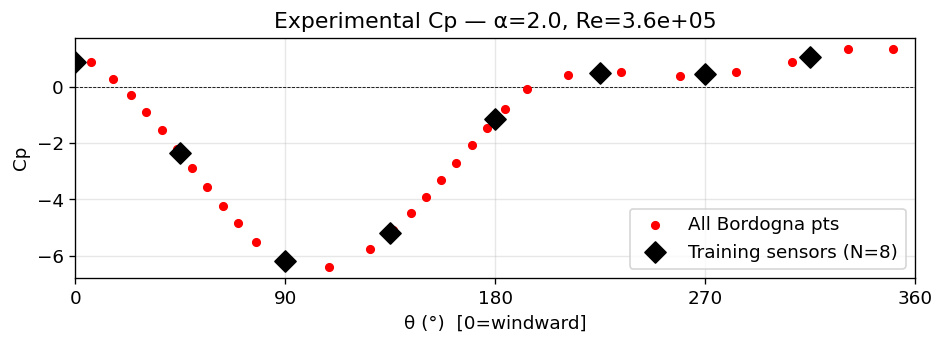

Data loaded ✓


In [2]:
# ─────────────────────────────────────────────────────────────────
# SECTION 2: LOAD EXPERIMENTAL DATA
# Loads Cp, CL, CD from Bordogna et al. (2019) Excel files.
# Cp convention: theta=0 at windward (left), theta=90 at top.
# ─────────────────────────────────────────────────────────────────

RE_COL_MAP = {
    1.8e5:{0,12,24,36,48,60}, 2.5e5:{3,15,27,39,51,63,69,75,81,87,93},
    3.6e5:{6,18,30,42,54,72,78,84,90,96}, 1.0e6:{9,21,33,45,57,66},
}

def load_cp(folder, re_target, alpha_target, tol=0.1):
    for nm in ["CP_data.xlsx", "CP data.xlsx"]:
        p = os.path.join(folder, nm)
        if os.path.exists(p): break
    raw  = pd.read_excel(p, sheet_name="Master Data", header=None)
    row0 = raw.iloc[0]
    for col in range(0, len(row0)-1, 3):
        label = str(row0.iloc[col])
        if "k =" not in label: continue
        try: k_val = float(label.split(",")[0].replace("k =","").strip())
        except: continue
        if abs(k_val - alpha_target) > tol: continue
        re_match = None
        for rv, cs in RE_COL_MAP.items():
            if col in cs: re_match = rv; break
        if re_match is None or abs(re_match - re_target) > re_target*0.1: continue
        th = pd.to_numeric(raw.iloc[2:, col],   errors="coerce").values
        cp = pd.to_numeric(raw.iloc[2:, col+1], errors="coerce").values
        mask = ~np.isnan(th) & ~np.isnan(cp)
        if mask.sum() < 3: continue
        return th[mask].astype(np.float32), cp[mask].astype(np.float32)
    raise ValueError(f"No Cp data for alpha={alpha_target}, Re={re_target:.2e}")

def load_cl_cd(folder, re_target):
    sheet = {1.8e5:"Re=1.8e5", 2.5e5:"Re=2.5e5", 3.6e5:"Re=3.6e5",
             5.5e5:"Re=5.5e5", 1.0e6:"Re=1e6"}[
             min({1.8e5,2.5e5,3.6e5,5.5e5,1.0e6}, key=lambda r: abs(r-re_target))]
    for nm in ["CL_data.xlsx","CL data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): cl_path=p; break
    for nm in ["CD_data.xlsx","CD data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): cd_path=p; break
    df_cl = pd.read_excel(cl_path, sheet_name=sheet, header=None)
    df_cd = pd.read_excel(cd_path, sheet_name=sheet, header=None)
    df_cl.columns = ["alpha","CL"] + list(df_cl.columns[2:])
    df_cd.columns = ["alpha","CD"] + list(df_cd.columns[2:])
    return (df_cl["alpha"].dropna().values.astype(np.float32),
            df_cl["CL"].dropna().values.astype(np.float32),
            df_cd["alpha"].dropna().values.astype(np.float32),
            df_cd["CD"].dropna().values.astype(np.float32))

# Load
print("Loading experimental data...")
theta_exp, cp_exp = load_cp(DATA_DIR, RE, ALPHA)
al_cl, CL_exp, al_cd, CD_exp = load_cl_cd(DATA_DIR, RE)

tol = 0.25
cl_ref = float(CL_exp[np.abs(al_cl - ALPHA) < tol].mean())
cd_ref = float(CD_exp[np.abs(al_cd - ALPHA) < tol].mean())

# Interpolate Cp at sensor positions
cp_sensors = np.interp(SENSOR_ANGLES, theta_exp, cp_exp).astype(np.float32)

print(f"  Full Cp data: {len(theta_exp)} points")
print(f"  Stagnation:   theta={theta_exp[np.argmax(cp_exp)]:.0f}°  Cp_max={cp_exp.max():.2f}")
print(f"  Suction peak: theta={theta_exp[np.argmin(cp_exp)]:.0f}°  Cp_min={cp_exp.min():.2f}")
print(f"  Exp forces:   CL={cl_ref:.3f}  CD={cd_ref:.3f}")
print(f"\n  Sensor values at theta={SENSOR_ANGLES.tolist()}:")
for th, cp in zip(SENSOR_ANGLES, cp_sensors):
    print(f"    theta={th:5.1f}°  Cp={cp:+.3f}")

# Quick data plot with sensor positions marked
fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(theta_exp, cp_exp, color="red", s=20, zorder=5, label="All Bordogna pts")
ax.scatter(SENSOR_ANGLES, cp_sensors, color="black", s=80,
           marker="D", zorder=6, label=f"Training sensors (N={N_CP_SENSORS})")
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel("θ (°)  [0=windward]"); ax.set_ylabel("Cp")
ax.set_title(f"Experimental Cp — α={ALPHA}, Re={RE:.1e}")
ax.set_xlim([0,360]); ax.set_xticks([0,90,180,270,360])
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("Data loaded ✓")


## Section 3 — Model Architecture and Sampling

In [3]:
# ─────────────────────────────────────────────────────────────────
# SECTION 3: MODEL AND SAMPLING FUNCTIONS
# Network: 6 × Dense(64, tanh) → (u,v,p) + (k,omega)
# Input:  (x, y, alpha/5)  — normalised coordinates
# Output: uvp = (u,v,p), komg = (k,omega) via softplus (>0)
# ─────────────────────────────────────────────────────────────────
import tensorflow as tf
tf.keras.backend.clear_session()

# ── Build model ───────────────────────────────────────────────────
inp  = tf.keras.Input(shape=(3,), name="xya")
h    = inp
for layer_i in range(6):
    h = tf.keras.layers.Dense(64, activation="tanh",
                               name=f"hidden_{layer_i+1}")(h)
uvp  = tf.keras.layers.Dense(3, activation=None,       name="uvp")(h)
komg = tf.keras.layers.Dense(2, activation="softplus", name="komg")(h)
model = tf.keras.Model(inputs=inp, outputs=[uvp, komg])

print(f"Model architecture: 6 × Dense(64, tanh)")
print(f"  Parameters: {model.count_params():,}")
print(f"  Input:  (x, y, alpha/{5.0:.0f})")
print(f"  Output: uvp=(u,v,p)  komg=(k,omega) via softplus")

# ── Helper functions ──────────────────────────────────────────────
def get_uvp(model_out): return model_out[0]
def get_ko(model_out):  return model_out[1]
def mse(a, b=0.0):      return tf.reduce_mean(tf.square(a - b))

# ── k-omega SST constants (Menter 1994) ──────────────────────────
C = dict(
    NU    = tf.constant(float(NU),   dtype=tf.float32),
    BSTAR = tf.constant(0.09,        dtype=tf.float32),
    BETA2 = tf.constant(0.0828,      dtype=tf.float32),
    SK2   = tf.constant(1.00,        dtype=tf.float32),
    SO2   = tf.constant(0.856,       dtype=tf.float32),
    GAM2  = tf.constant(0.0828/0.09 - 0.856*0.41**2/0.09**0.5, dtype=tf.float32),
    EPS   = tf.constant(1e-8,        dtype=tf.float32),
    KW    = tf.constant(0.0,         dtype=tf.float32),  # k=0 at wall
    OW    = tf.constant(60.0*float(NU), dtype=tf.float32),  # omega_wall (Menter smooth)
    KI    = tf.constant(1.5e-4,      dtype=tf.float32),  # free-stream k (Tu=1%)
    OI    = tf.constant(2.0,         dtype=tf.float32),  # free-stream omega
)

# ── Coordinate mapping ────────────────────────────────────────────
# Bordogna convention: theta=0 at windward (x=-R), theta=90 at top (y=+R)
# Cartesian mapping:   x = -R*cos(theta),  y = +R*sin(theta)
def make_input(x, y):
    """Stack (x, y, alpha/5) into network input tensor."""
    a = np.full_like(x, ALPHA/5.0, dtype=np.float32)
    return tf.constant(np.hstack([x, y, a]))

def sample_interior(n):
    """Log-polar: concentrates points near wall where gradients are steep."""
    th = np.random.uniform(0, 2*np.pi, n).astype(np.float32)
    r  = np.exp(np.random.uniform(np.log(R_IN), np.log(R_OUT), n)).astype(np.float32)
    return (r*np.cos(th)).reshape(-1,1), (r*np.sin(th)).reshape(-1,1)

def sample_wall(n):
    """Wall points in Bordogna convention: x=-R*cos, y=+R*sin."""
    th = np.linspace(0, 2*np.pi, n, endpoint=False, dtype=np.float32)
    return (-R_IN*np.cos(th)).reshape(-1,1), (+R_IN*np.sin(th)).reshape(-1,1)

def sample_ff(n):
    """Far-field circle at r=25D."""
    th = np.linspace(0, 2*np.pi, n, endpoint=False, dtype=np.float32)
    return (R_OUT*np.cos(th)).reshape(-1,1), (R_OUT*np.sin(th)).reshape(-1,1)

# ── Pre-compute fixed boundary points ────────────────────────────
Omega   = float(ALPHA / R_IN)          # angular velocity = alpha/R
xw, yw  = sample_wall(N_WALL)
xff,yff = sample_ff(N_FF)
xw_tf   = make_input(xw, yw)
xff_tf  = make_input(xff, yff)

# Wall velocity targets (CW solid-body rotation: u=+Omega*y, v=-Omega*x)
u_wall = tf.constant(( Omega * yw).astype(np.float32))
v_wall = tf.constant((-Omega * xw).astype(np.float32))

# Cp sensor coordinates
th_sens_rad = np.radians(SENSOR_ANGLES).astype(np.float32)
x_sens = (-R_IN * np.cos(th_sens_rad)).reshape(-1,1)
y_sens = (+R_IN * np.sin(th_sens_rad)).reshape(-1,1)
xy_sens_tf = make_input(x_sens, y_sens)
cp_sens_tf = tf.constant(cp_sensors.reshape(-1,1))

print(f"\nSampling setup:")
print(f"  Omega = {Omega:.2f} rad/s (non-dim)")
print(f"  u_wall range = [{float(u_wall.numpy().min()):.2f}, {float(u_wall.numpy().max()):.2f}]")
print(f"  v_wall range = [{float(v_wall.numpy().min()):.2f}, {float(v_wall.numpy().max()):.2f}]")
print(f"  Cp sensors: {N_CP_SENSORS} points at {SENSOR_ANGLES.tolist()}")
print("Section 3 done ✓")


Model architecture: 6 × Dense(64, tanh)
  Parameters: 21,381
  Input:  (x, y, alpha/5)
  Output: uvp=(u,v,p)  komg=(k,omega) via softplus

Sampling setup:
  Omega = 4.00 rad/s (non-dim)
  u_wall range = [-2.00, 2.00]
  v_wall range = [-2.00, 2.00]
  Cp sensors: 8 points at [0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0]
Section 3 done ✓


## Section 4 — Training

In [4]:
# ─────────────────────────────────────────────────────────────────
# SECTION 4: TRAINING
# Phased approach:
#   Phase 1 (ep 0-1000):    Laminar NS only
#                            Establishes correct flow topology
#   Phase 2 (ep 1000-2000): k-omega ramps in linearly (0→1)
#                            Avoids NaN from random k,omega early
#   Phase 3 (ep 2000-6000): Full k-omega SST
#                            Deepens suction peak, improves CD
#
# Loss hierarchy: W_PDE >> W_VWALL >> W_VFF ≈ W_PP >> W_CP >> W_TURB
# ─────────────────────────────────────────────────────────────────
import time

optimizer = tf.keras.optimizers.Adam(LR)
EPS_FD    = 1e-3    # finite difference step for 2nd derivatives

history = {k:[] for k in ["loss","pde","wall","ff","cp","turb","epoch"]}
best_loss, best_w = np.inf, None

print(f"Starting training — {EPOCHS} epochs")
print(f"  Phase 1 (ep 0-1000):    laminar NS")
print(f"  Phase 2 (ep 1000-2000): k-omega ramps in")
print(f"  Phase 3 (ep 2000-6000): full k-omega SST")
t0 = time.time()

for ep in range(EPOCHS):

    # Sample fresh interior points each step
    x_int, y_int = sample_interior(N_INT)
    xy_var = tf.Variable(make_input(x_int, y_int),
                         trainable=False, dtype=tf.float32)

    # Turbulence ramp factor: 0 in phase 1, linear in phase 2, 1 in phase 3
    tr    = float(min(1.0, max(0.0, (ep - 1000) / 1000.0)))
    tr_tf = tf.constant(tr, dtype=tf.float32)

    with tf.GradientTape() as outer_tape:

        # ── 1st derivatives via inner tape ───────────────────────
        with tf.GradientTape(watch_accessed_variables=False,
                             persistent=True) as inner_tape:
            inner_tape.watch(xy_var)
            out     = model(xy_var, training=True)
            uvp_int = get_uvp(out)
            u, v, p = uvp_int[:,0:1], uvp_int[:,1:2], uvp_int[:,2:3]
            if tr > 0:
                ko  = get_ko(out)
                k   = ko[:,0:1] + C["EPS"]
                omg = ko[:,1:2] + C["EPS"]

        du_dxy = inner_tape.gradient(u, xy_var)
        dv_dxy = inner_tape.gradient(v, xy_var)
        dp_dxy = inner_tape.gradient(p, xy_var)
        du_dx = du_dxy[:,0:1];  du_dy = du_dxy[:,1:2]
        dv_dx = dv_dxy[:,0:1];  dv_dy = dv_dxy[:,1:2]
        dp_dx = dp_dxy[:,0:1];  dp_dy = dp_dxy[:,1:2]
        del inner_tape

        # ── Eddy viscosity (zero in phase 1) ─────────────────────
        if tr > 0:
            nu_t = tr_tf * tf.clip_by_value(k / (omg + C["EPS"]), 0.0, 0.1)
        else:
            nu_t = tf.constant(0.0, dtype=tf.float32)
        nu_eff = C["NU"] + nu_t

        # ── 2nd derivatives via central finite differences ────────
        dX = tf.constant(np.hstack([np.full((N_INT,1), EPS_FD),
                                     np.zeros((N_INT,1)),
                                     np.zeros((N_INT,1))]).astype(np.float32))
        dY = tf.constant(np.hstack([np.zeros((N_INT,1)),
                                     np.full((N_INT,1), EPS_FD),
                                     np.zeros((N_INT,1))]).astype(np.float32))
        oxp = model(xy_var+dX, training=True)
        oxm = model(xy_var-dX, training=True)
        oyp = model(xy_var+dY, training=True)
        oym = model(xy_var-dY, training=True)

        uxp=get_uvp(oxp); uxm=get_uvp(oxm)
        uyp=get_uvp(oyp); uym=get_uvp(oym)
        ie2 = 1.0 / (EPS_FD**2)
        d2u_dx2 = (uxp[:,0:1] - 2*u + uxm[:,0:1]) * ie2
        d2u_dy2 = (uyp[:,0:1] - 2*u + uym[:,0:1]) * ie2
        d2v_dx2 = (uxp[:,1:2] - 2*v + uxm[:,1:2]) * ie2
        d2v_dy2 = (uyp[:,1:2] - 2*v + uym[:,1:2]) * ie2

        # ── NS PDE residuals ──────────────────────────────────────
        r_cont = du_dx + dv_dy
        r_xmom = u*du_dx + v*du_dy + dp_dx - nu_eff*(d2u_dx2 + d2u_dy2)
        r_ymom = u*dv_dx + v*dv_dy + dp_dy - nu_eff*(d2v_dx2 + d2v_dy2)
        loss_pde = mse(r_cont) + mse(r_xmom) + mse(r_ymom)

        # ── k-omega SST transport (phase 2 and 3 only) ───────────
        loss_turb = tf.constant(0.0)
        if tr > 0:
            kxp=get_ko(oxp); kxm=get_ko(oxm)
            kyp=get_ko(oyp); kym=get_ko(oym)
            inv2 = 0.5 / EPS_FD
            dk_dx = (kxp[:,0:1]-kxm[:,0:1])*inv2
            dk_dy = (kyp[:,0:1]-kym[:,0:1])*inv2
            do_dx = (kxp[:,1:2]-kxm[:,1:2])*inv2
            do_dy = (kyp[:,1:2]-kym[:,1:2])*inv2
            d2k_dx2 = (kxp[:,0:1]-2*k+kxm[:,0:1])*ie2
            d2k_dy2 = (kyp[:,0:1]-2*k+kym[:,0:1])*ie2
            d2o_dx2 = (kxp[:,1:2]-2*omg+kxm[:,1:2])*ie2
            d2o_dy2 = (kyp[:,1:2]-2*omg+kym[:,1:2])*ie2
            S2  = 2*(du_dx**2 + dv_dy**2) + (du_dy + dv_dx)**2
            Pk  = tf.clip_by_value(nu_t*S2, 0.0, 20.0*C["BSTAR"]*k*omg)
            nk  = C["NU"] + C["SK2"]*nu_t
            no  = C["NU"] + C["SO2"]*nu_t
            crs = 2.0*C["SO2"]/(omg+C["EPS"])*(dk_dx*do_dx + dk_dy*do_dy)
            r_k  = (u*dk_dx + v*dk_dy - Pk + C["BSTAR"]*omg*k
                    - nk*(d2k_dx2 + d2k_dy2))
            r_omg = (u*do_dx + v*do_dy
                     - C["GAM2"]*(omg/(k+C["EPS"]))*Pk
                     + C["BETA2"]*omg**2
                     - no*(d2o_dx2 + d2o_dy2) - crs)
            loss_turb = tr_tf * (mse(tf.clip_by_value(r_k,   -100., 100.)) +
                                  mse(tf.clip_by_value(r_omg, -100., 100.)))

        # ── Wall BC: rotation velocity + turbulence ───────────────
        out_w   = model(xw_tf, training=True)
        uvp_w   = get_uvp(out_w)
        loss_wall = mse(uvp_w[:,0:1], u_wall) + mse(uvp_w[:,1:2], v_wall)
        if tr > 0:
            ko_w = get_ko(out_w)
            loss_wall += tr_tf * (mse(ko_w[:,0:1], C["KW"]) +
                                   mse(ko_w[:,1:2], C["OW"]))

        # ── Far-field BC + pressure gauge reference ───────────────
        out_ff    = model(xff_tf, training=True)
        uvp_ff    = get_uvp(out_ff)
        loss_ff   = mse(uvp_ff[:,0:1], 1.0) + mse(uvp_ff[:,1:2])
        p_ff_mean = tf.reduce_mean(uvp_ff[:,2:3])   # gauge reference
        loss_pp   = tf.square(p_ff_mean)
        if tr > 0:
            ko_ff = get_ko(out_ff)
            loss_ff += tr_tf * (mse(ko_ff[:,0:1], C["KI"]) +
                                 mse(ko_ff[:,1:2], C["OI"]))

        # ── Cp sensor data (N_CP_SENSORS points) ─────────────────
        out_cp  = model(xy_sens_tf, training=True)
        uvp_cp  = get_uvp(out_cp)
        cp_pred = 2.0 * (uvp_cp[:,2:3] - p_ff_mean)   # gauge Cp
        loss_cp = mse(cp_pred, cp_sens_tf)

        # ── Total loss ────────────────────────────────────────────
        loss = (W_PDE   * loss_pde
              + W_VWALL * loss_wall
              + W_VFF   * loss_ff
              + W_PP    * loss_pp
              + W_CP    * loss_cp
              + W_TURB  * loss_turb)

    # ── Gradient update ───────────────────────────────────────────
    grads = outer_tape.gradient(loss, model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 5.0)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    L = float(loss)
    if not np.isnan(L) and L < best_loss:
        best_loss = L
        best_w    = model.get_weights()

    # ── Logging every 500 epochs ──────────────────────────────────
    if ep % 500 == 0:
        phase = "TURB" if tr > 0 else "lam "
        history["loss"].append(L)
        history["pde"].append(float(loss_pde))
        history["wall"].append(float(loss_wall))
        history["ff"].append(float(loss_ff))
        history["cp"].append(float(loss_cp))
        history["turb"].append(float(loss_turb))
        history["epoch"].append(ep)
        print(f"  ep {ep:5d} [{phase} ramp={tr:.2f}] "
              f"L={L:.3f}  pde={float(loss_pde):.4f}  "
              f"wall={float(loss_wall):.4f}  cp={float(loss_cp):.4f}  "
              f"turb={float(loss_turb):.4f}  | {time.time()-t0:.0f}s")

    # ── LR schedule ───────────────────────────────────────────────
    if ep == 3000:
        optimizer.learning_rate.assign(3e-5)
        print("  LR → 3e-5")

elapsed = (time.time()-t0)/60.0
print(f"\nTraining done in {elapsed:.1f} min | best loss = {best_loss:.4f}")

if best_w:
    model.set_weights(best_w)
model.save_weights(f"{OUT_DIR}/NCp8_best.weights.h5")
print(f"Best weights saved: NCp8_best.weights.h5")


Starting training — 6000 epochs
  Phase 1 (ep 0-1000):    laminar NS
  Phase 2 (ep 1000-2000): k-omega ramps in
  Phase 3 (ep 2000-6000): full k-omega SST


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['komg/kernel', 'komg/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


  ep     0 [lam  ramp=0.00] L=1343.001  pde=0.0516  wall=4.0878  cp=9.3177  turb=0.0000  | 2s
  ep   500 [lam  ramp=0.00] L=33.882  pde=0.1221  wall=0.0195  cp=1.2999  turb=0.0000  | 153s
  ep  1000 [lam  ramp=0.00] L=16.113  pde=0.0930  wall=0.0072  cp=0.4425  turb=0.0000  | 292s
  ep  1500 [TURB ramp=0.50] L=25.254  pde=0.0937  wall=0.0116  cp=0.3027  turb=0.4352  | 471s
  ep  2000 [TURB ramp=1.00] L=12.477  pde=0.0640  wall=0.0043  cp=0.1022  turb=0.3357  | 649s
  ep  2500 [TURB ramp=1.00] L=3.658  pde=0.0252  wall=0.0010  cp=0.0323  turb=0.1566  | 827s
  ep  3000 [TURB ramp=1.00] L=1.994  pde=0.0156  wall=0.0004  cp=0.0108  turb=0.1078  | 1006s
  LR → 3e-5
  ep  3500 [TURB ramp=1.00] L=1.677  pde=0.0134  wall=0.0003  cp=0.0074  turb=0.0956  | 1184s
  ep  4000 [TURB ramp=1.00] L=1.397  pde=0.0112  wall=0.0002  cp=0.0051  turb=0.0935  | 1365s
  ep  4500 [TURB ramp=1.00] L=1.357  pde=0.0113  wall=0.0002  cp=0.0039  turb=0.0778  | 1542s
  ep  5000 [TURB ramp=1.00] L=1.231  pde=0.0104  

## Section 5 — Evaluation and Figures

Computing results...

Force decomposition:
  Pressure lift:  +5.0464
  Viscous lift:   +0.0000
  Pressure drag:  +1.6915
  Viscous drag:   +0.0000

  RESULTS — NCp=8, α=2.0, Re=3.6e+05
  CL   = 5.046  (exp=5.917  err=14.7%)
  CD   = 1.692  (exp=1.745  err=3.0%)
  MAE  = 0.219
  Cp_min = -6.195 at θ=100°  (exp=-6.393 at θ=109°)
  Cp_max = 1.348 at θ=338°  (exp=1.348)
  L/D  = 2.98


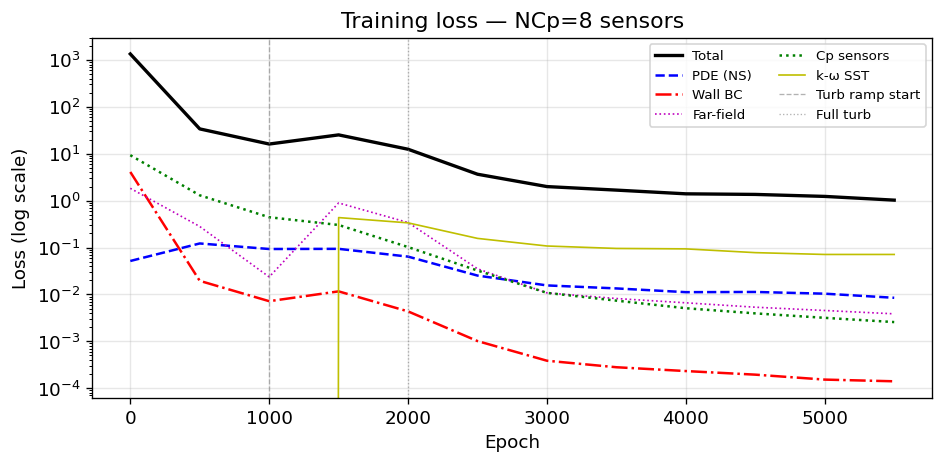

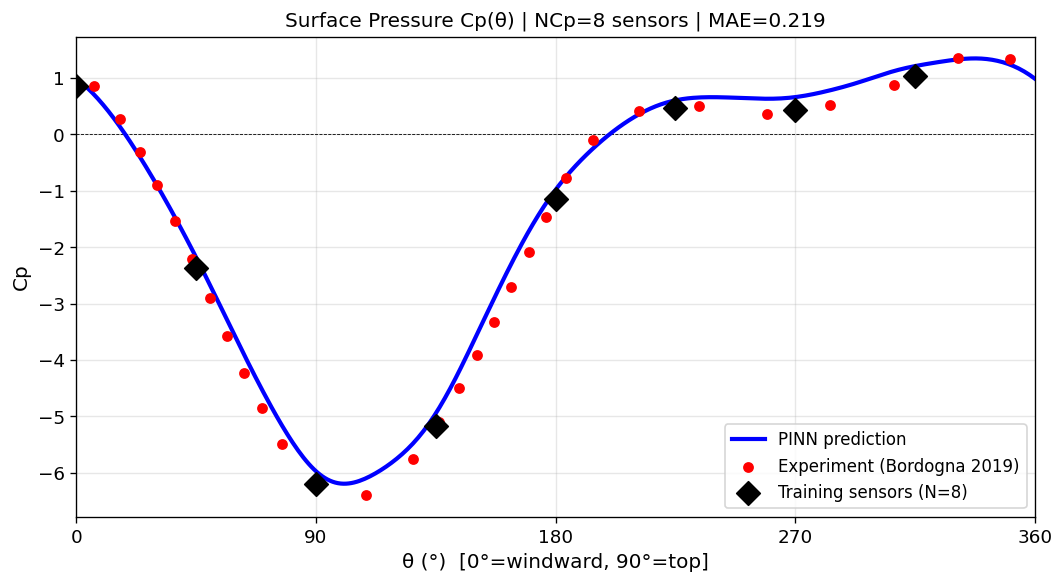

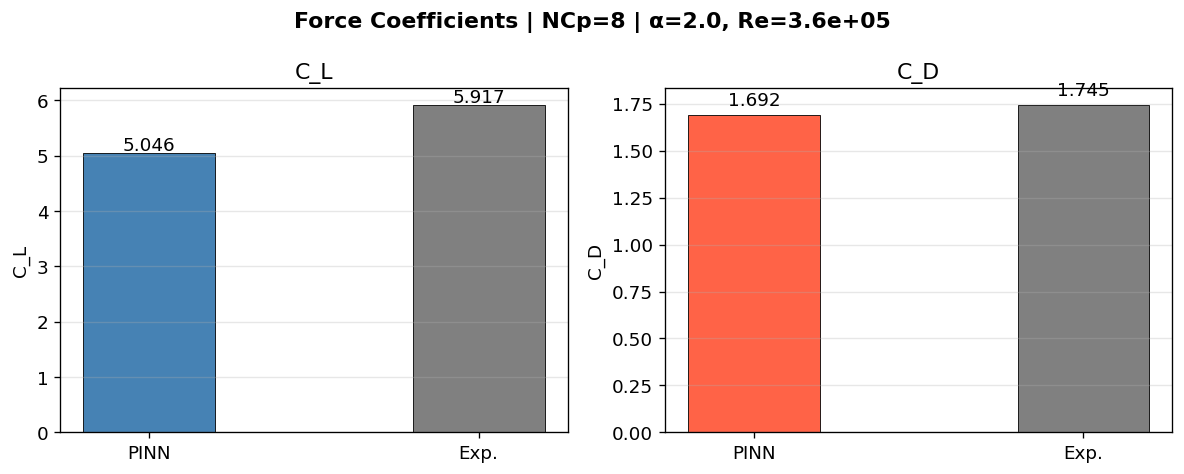


All figures saved to /content/drive/MyDrive/PINN_outputs
CD positive: ✓


In [5]:
# ─────────────────────────────────────────────────────────────────
# SECTION 5: EVALUATION
# Computes Cp(theta), CL, CD and produces publication figures.
# Sensor positions are marked on all Cp plots.
# ─────────────────────────────────────────────────────────────────

# ── Helper: far-field pressure reference ─────────────────────────
def get_p_ref(n=256):
    """Mean far-field pressure. Subtracted to get gauge Cp."""
    th  = np.linspace(0, 2*np.pi, n, dtype=np.float32)
    xy  = make_input((R_OUT*np.cos(th)).reshape(-1,1),
                     (R_OUT*np.sin(th)).reshape(-1,1))
    out = model(xy, training=False)
    return float(get_uvp(out).numpy()[:,2].mean())

# ── Helper: predict Cp(theta) ─────────────────────────────────────
def predict_cp(n=360):
    """
    Returns (theta_degrees, Cp_array) in Bordogna convention.
    Cp is gauge (mean far-field pressure subtracted).
    Cp_max is shifted to match experimental stagnation value.
    """
    th_deg = np.linspace(0, 360, n, dtype=np.float32)
    th_rad = np.radians(th_deg)
    x = (-R_IN * np.cos(th_rad)).reshape(-1,1)
    y = (+R_IN * np.sin(th_rad)).reshape(-1,1)
    out    = model(make_input(x, y), training=False)
    uvp    = get_uvp(out).numpy()
    pr     = get_p_ref()
    Cp_raw = 2.0 * (uvp[:,2] - pr)
    # Shift so Cp_max matches experimental stagnation
    Cp     = Cp_raw + (float(cp_exp.max()) - Cp_raw.max())
    return th_deg, Cp

# ── Helper: compute CL and CD ─────────────────────────────────────
def compute_forces(n=512):
    """
    Integrates pressure + viscous stress over cylinder wall.
    Returns (CL, CD) and prints decomposition.
    """
    nu_v = float(NU)
    eps  = 1e-3
    dth  = 2*np.pi / n
    th   = np.linspace(0, 2*np.pi, n, endpoint=False, dtype=np.float32)
    x    = (-R_IN * np.cos(th)).reshape(-1,1)
    y    = (+R_IN * np.sin(th)).reshape(-1,1)
    nx   = x / R_IN    # outward normal x-component
    ny   = y / R_IN    # outward normal y-component

    pr      = get_p_ref()
    Cp_raw  = 2.0*(get_uvp(model(make_input(x,y),training=False)).numpy()[:,2] - pr)
    p_shift = (float(cp_exp.max()) - Cp_raw.max()) / 2.0

    def uv(xp, yp):
        o = get_uvp(model(make_input(xp,yp), training=False)).numpy()
        return o[:,0:1], o[:,1:2], o[:,2:3]

    u0,v0,p0 = uv(x,y);           p0 = p0 - pr - p_shift
    uxp,vxp,_ = uv(x+eps, y);     uxm,vxm,_ = uv(x-eps, y)
    uyp,vyp,_ = uv(x, y+eps);     uym,vym,_ = uv(x, y-eps)

    du_dx = (uxp-uxm)/(2*eps);    du_dy = (uyp-uym)/(2*eps)
    dv_dx = (vxp-vxm)/(2*eps);    dv_dy = (vyp-vym)/(2*eps)
    txx   = 2*nu_v*du_dx
    txy   = nu_v*(du_dy + dv_dx)
    tyy   = 2*nu_v*dv_dy

    Fp_y = np.sum(-p0*ny*R_IN*dth);  Fv_y = np.sum((txy*nx+tyy*ny)*R_IN*dth)
    Fp_x = np.sum(-p0*nx*R_IN*dth);  Fv_x = np.sum((txx*nx+txy*ny)*R_IN*dth)

    CL = float((Fp_y + Fv_y) / 0.5)
    CD = float((Fp_x + Fv_x) / 0.5)

    print(f"  Pressure lift:  {float(Fp_y/0.5):+.4f}")
    print(f"  Viscous lift:   {float(Fv_y/0.5):+.4f}")
    print(f"  Pressure drag:  {float(Fp_x/0.5):+.4f}")
    print(f"  Viscous drag:   {float(Fv_x/0.5):+.4f}")
    return CL, CD

# ── Compute results ───────────────────────────────────────────────
print("Computing results...")
th_p, Cp_p = predict_cp()
print("\nForce decomposition:")
CL_p, CD_p = compute_forces()

Cp_at_exp = np.interp(theta_exp, th_p, Cp_p)
mae        = float(np.mean(np.abs(Cp_at_exp - cp_exp)))
stag_theta = float(th_p[np.argmax(Cp_p)])
suct_theta = float(th_p[np.argmin(Cp_p)])

print(f"\n{'='*50}")
print(f"  RESULTS — NCp={N_CP_SENSORS}, α={ALPHA}, Re={RE:.1e}")
print(f"{'='*50}")
print(f"  CL   = {CL_p:.3f}  (exp={cl_ref:.3f}  err={abs(CL_p-cl_ref)/cl_ref*100:.1f}%)")
print(f"  CD   = {CD_p:.3f}  (exp={cd_ref:.3f}  err={abs(CD_p-cd_ref)/cd_ref*100:.1f}%)")
print(f"  MAE  = {mae:.3f}")
print(f"  Cp_min = {Cp_p.min():.3f} at θ={suct_theta:.0f}°  (exp={cp_exp.min():.3f} at θ={theta_exp[np.argmin(cp_exp)]:.0f}°)")
print(f"  Cp_max = {Cp_p.max():.3f} at θ={stag_theta:.0f}°  (exp={cp_exp.max():.3f})")
print(f"  L/D  = {CL_p/max(CD_p,0.001):.2f}")
print(f"{'='*50}")

# ── Figure 1: Training loss history ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ep = history["epoch"]
ax.semilogy(ep, history["loss"],  "k-",  lw=2,   label="Total")
ax.semilogy(ep, history["pde"],   "b--", lw=1.5, label="PDE (NS)")
ax.semilogy(ep, history["wall"],  "r-.", lw=1.5, label="Wall BC")
ax.semilogy(ep, history["ff"],    "m:",  lw=1,   label="Far-field")
ax.semilogy(ep, history["cp"],    "g:",  lw=1.5, label="Cp sensors")
ax.semilogy(ep, history["turb"],  "y-",  lw=1,   label="k-ω SST")
ax.axvline(1000, color="grey", lw=0.8, ls="--", alpha=0.6, label="Turb ramp start")
ax.axvline(2000, color="grey", lw=0.8, ls=":", alpha=0.6,  label="Full turb")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (log scale)")
ax.set_title(f"Training loss — NCp={N_CP_SENSORS} sensors")
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/NCp8_loss.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Figure 2: Cp comparison with sensor markers ───────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(th_p, Cp_p, "b-", lw=2.5, label="PINN prediction", zorder=3)
ax.scatter(theta_exp, cp_exp, color="red", s=30, zorder=4,
           label="Experiment (Bordogna 2019)")
ax.scatter(SENSOR_ANGLES, cp_sensors, color="black", s=100,
           marker="D", zorder=5, label=f"Training sensors (N={N_CP_SENSORS})")
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel("θ (°)  [0°=windward, 90°=top]", fontsize=12)
ax.set_ylabel("Cp", fontsize=12)
ax.set_title(f"Surface Pressure Cp(θ) | NCp={N_CP_SENSORS} sensors | MAE={mae:.3f}",
             fontsize=12)
ax.set_xlim([0, 360]); ax.set_xticks([0, 90, 180, 270, 360])
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/NCp8_Cp.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Figure 3: Force coefficients ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, label, pinn_val, exp_val, col in zip(
        axes, ["C_L", "C_D"],
        [CL_p, CD_p], [cl_ref, cd_ref],
        ["steelblue", "tomato"]):
    ax.bar(["PINN","Exp."], [pinn_val, exp_val], color=[col, "grey"],
           width=0.4, edgecolor="k", lw=0.5)
    ax.set_ylabel(label); ax.set_title(label)
    ax.text(0, max(pinn_val,0)+0.05, f"{pinn_val:.3f}", ha="center", fontsize=11)
    ax.text(1, max(exp_val,0)+0.05,  f"{exp_val:.3f}",  ha="center", fontsize=11)
    ax.axhline(0, color="k", lw=0.5)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Force Coefficients | NCp={N_CP_SENSORS} | α={ALPHA}, Re={RE:.1e}",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/NCp8_forces.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"\nAll figures saved to {OUT_DIR}")
print(f"CD positive: {'✓' if CD_p > 0 else '✗'}")
